In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [42]:
df  = pd.read_csv(r"alzheimers_prediction_dataset.csv")
df

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,Russia,60,Female,3,22.6,High,Former,Never,No,No,...,Average,High,Unemployed,Widowed,No,Medium,High,Medium,Rural,No
74279,UK,58,Male,18,30.6,Low,Never,Occasionally,Yes,No,...,Average,Medium,Unemployed,Single,No,Medium,High,High,Rural,No
74280,Spain,57,Female,13,28.2,Medium,Never,Regularly,No,No,...,Healthy,Low,Employed,Single,Yes,High,Low,Low,Rural,No
74281,Brazil,73,Female,7,29.0,Low,Never,Regularly,No,No,...,Healthy,Low,Employed,Widowed,No,Low,Low,High,Rural,No


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Family History 

In [44]:
df.isna().sum()

Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban vs Rural Living             

In [45]:

columns_to_drop = ["BMI", "Marital Status","Air Pollution Exposure", "Employment Status", "Income Level", "Urban vs Rural Living", "Country"]
df = df.drop(columns=columns_to_drop)


df


,Age,Gender,Education Level,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels,Alzheimer’s Diagnosis
0,90,Male,1,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,No,Low,High,No
1,72,Male,7,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,No,High,High,No
2,86,Female,19,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,No,Low,High,No
3,53,Male,17,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,No,High,Low,No
4,58,Female,3,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,No,Low,High,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,60,Female,3,High,Former,Never,No,No,High,No,42,Medium,Poor,Average,No,Medium,Medium,No
74279,58,Male,18,Low,Never,Occasionally,Yes,No,Normal,No,42,Low,Poor,Average,No,Medium,High,No
74280,57,Female,13,Medium,Never,Regularly,No,No,High,Yes,61,Low,Good,Healthy,Yes,High,Low,No
74281,73,Female,7,Low,Never,Regularly,No,No,High,No,97,High,Good,Healthy,No,Low,High,No


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df["Alzheimer’s Diagnosis"].value_counts()

Alzheimer’s Diagnosis
No     43570
Yes    30713
Name: count, dtype: int64

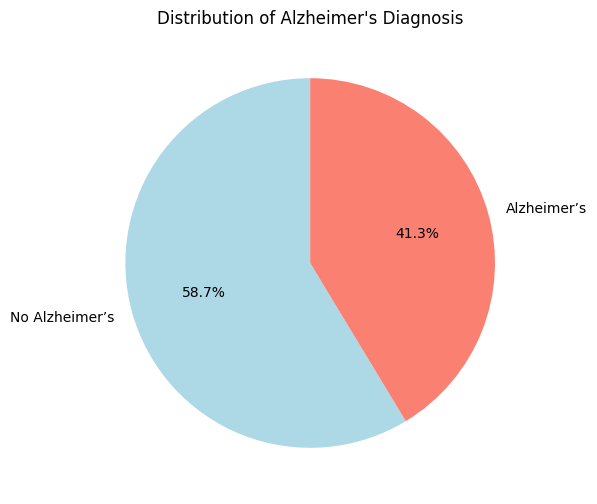

In [48]:
diagnosis_counts = df["Alzheimer’s Diagnosis"].value_counts()

labels = ["No Alzheimer’s", "Alzheimer’s"]
plt.figure(figsize=(6, 6))
plt.pie(diagnosis_counts, labels=labels, autopct="%1.1f%%", colors=["lightblue", "salmon"], startangle=90)
plt.title("Distribution of Alzheimer's Diagnosis")
plt.show()

In [49]:
grouped_percentage = df.groupby("Gender")["Alzheimer’s Diagnosis"].value_counts(normalize=True).unstack() * 100

grouped_percentage

Alzheimer’s Diagnosis,No,Yes
Gender,,
Female,58.721039,41.278961
Male,58.586704,41.413296


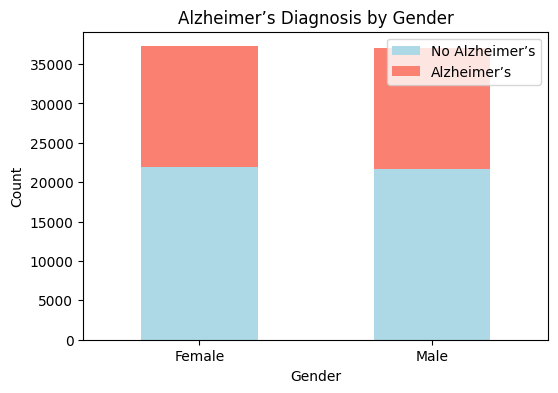

In [50]:
grouped_data = df.groupby("Gender")["Alzheimer’s Diagnosis"].value_counts().unstack()

grouped_data.plot(kind="bar", stacked=True, figsize=(6, 4), color=["lightblue", "salmon"])

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Alzheimer’s Diagnosis by Gender")
plt.legend(["No Alzheimer’s", "Alzheimer’s"])
plt.xticks(rotation=0)  
plt.show()

In [51]:
df["Education Level"].unique()

array([ 1,  7, 19, 17,  3,  2, 18, 11, 15, 10,  6, 13, 12,  4, 16,  5, 14,
        0,  8,  9])

In [52]:
df["Physical Activity Level"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

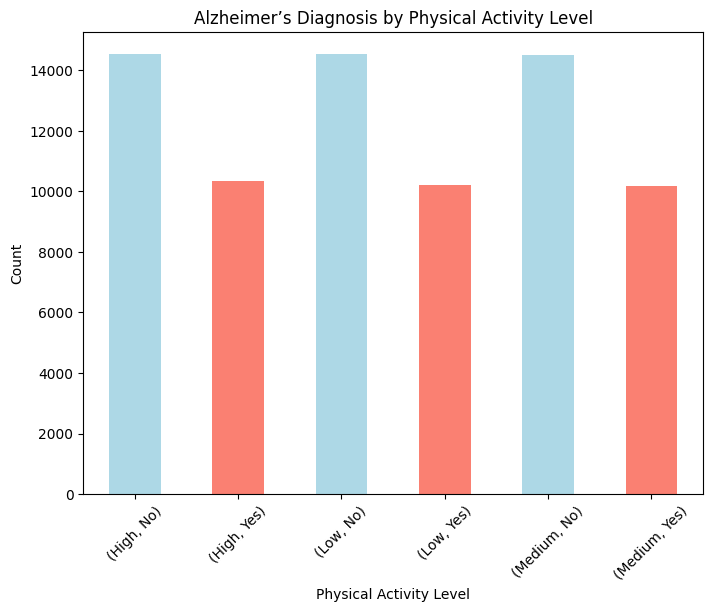

In [53]:
grouped_data = df.groupby("Physical Activity Level")["Alzheimer’s Diagnosis"].value_counts()

grouped_data.plot(kind="bar", stacked=True, figsize=(8, 6), color=["lightblue", "salmon"])

plt.xlabel("Physical Activity Level")
plt.ylabel("Count")
plt.title("Alzheimer’s Diagnosis by Physical Activity Level")
plt.xticks(rotation=45)  
plt.show()

In [54]:
df['Smoking Status'].value_counts()

Smoking Status
Current    24915
Never      24740
Former     24628
Name: count, dtype: int64

In [55]:
df['Alcohol Consumption'].value_counts()

Alcohol Consumption
Never           24865
Regularly       24738
Occasionally    24680
Name: count, dtype: int64

In [56]:
df['Diabetes'].value_counts()


Diabetes
No     59527
Yes    14756
Name: count, dtype: int64

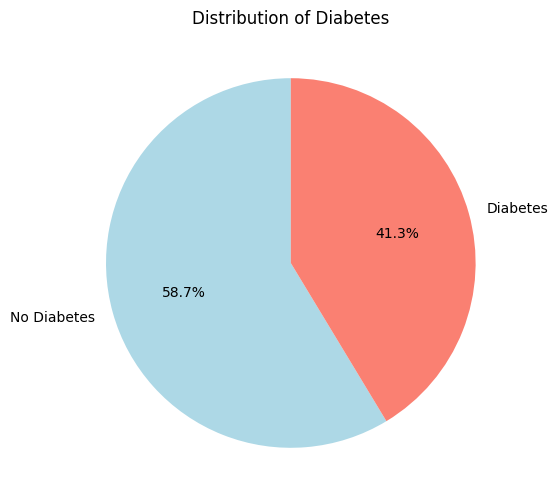

In [57]:
Diabetes_counts = df["Diabetes"].value_counts()

labels = ["No Diabetes", "Diabetes"]
plt.figure(figsize=(6, 6))
plt.pie(diagnosis_counts, labels=labels, autopct="%1.1f%%", colors=["lightblue", "salmon"], startangle=90)
plt.title("Distribution of Diabetes")
plt.show()

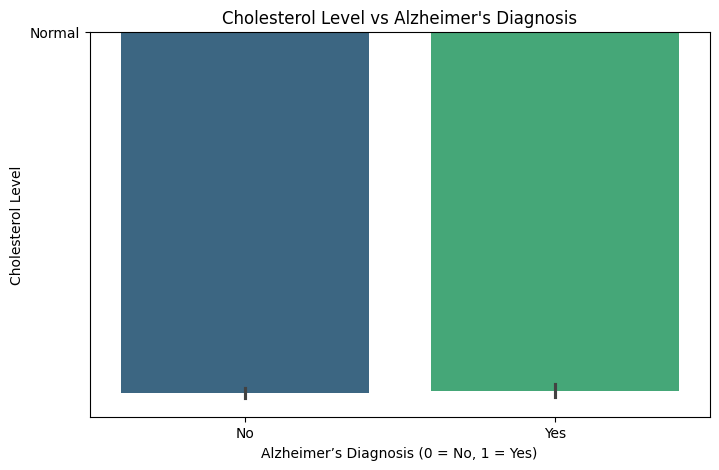

In [58]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["Alzheimer’s Diagnosis"], y=df["Cholesterol Level"], palette="viridis")
plt.xlabel("Alzheimer’s Diagnosis (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol Level")
plt.title("Cholesterol Level vs Alzheimer's Diagnosis")
plt.show()

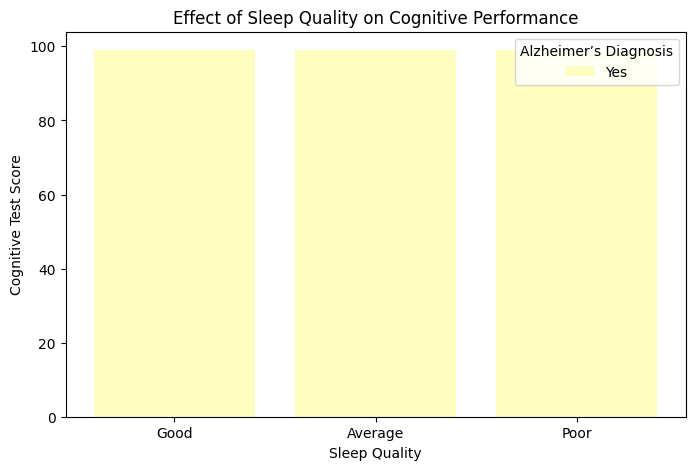

In [62]:
unique_diagnoses = df["Alzheimer’s Diagnosis"].unique()
colors = plt.cm.magma(np.linspace(0, 1, len(unique_diagnoses)))

plt.figure(figsize=(8, 5))
for i, diagnosis in enumerate(unique_diagnoses):
    subset = df[df["Alzheimer’s Diagnosis"] == diagnosis]

plt.bar(subset["Sleep Quality"], subset["Cognitive Test Score"], 
            color=colors[i], label=diagnosis)

plt.xlabel("Sleep Quality")
plt.ylabel("Cognitive Test Score")
plt.title("Effect of Sleep Quality on Cognitive Performance")
plt.legend(title="Alzheimer’s Diagnosis")
plt.show()

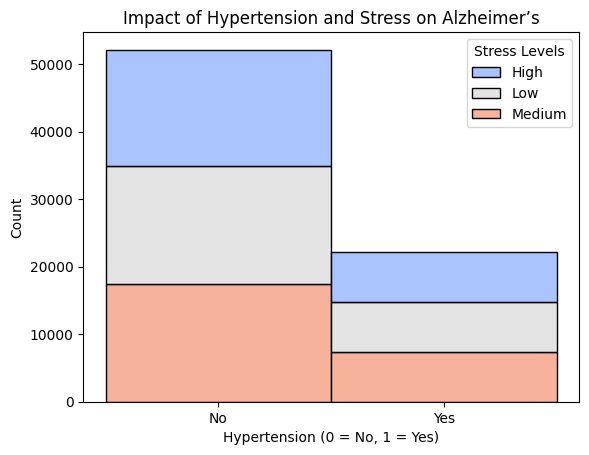

In [64]:
sns.histplot(data=df, x="Hypertension", hue="Stress Levels", multiple="stack", palette="coolwarm", discrete=True)

plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Impact of Hypertension and Stress on Alzheimer’s")
plt.legend
plt.show()

In [65]:


label_encoder = LabelEncoder()

categorical_columns = ["Gender", "Education Level", "Smoking Status", "Alcohol Consumption", 
                       "Dietary Habits",  "Genetic Risk Factor (APOE-ε4 allele)", "Diabetes","Hypertension",
                       "Social Engagement Level", "Stress Levels", "Alzheimer’s Diagnosis","Physical Activity Level","Cholesterol Level","Family History of Alzheimer’s","Depression Level","Sleep Quality"]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df


,Age,Gender,Education Level,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels,Alzheimer’s Diagnosis
0,90,1,1,2,2,1,0,0,1,0,90,1,2,1,0,1,0,0
1,72,1,7,2,1,0,0,0,1,0,65,1,1,1,0,0,0,0
2,86,0,19,0,0,1,0,1,1,0,43,0,1,0,0,1,0,0
3,53,1,17,1,2,2,1,0,1,0,81,2,0,1,0,0,1,0
4,58,0,3,0,1,0,1,0,1,0,49,0,2,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,60,0,3,0,1,0,0,0,0,0,42,2,2,0,0,2,2,0
74279,58,1,18,1,2,1,1,0,1,0,42,1,2,0,0,2,0,0
74280,57,0,13,2,2,2,0,0,0,1,61,1,1,1,1,0,1,0
74281,73,0,7,1,2,2,0,0,0,0,97,0,1,1,0,1,0,0


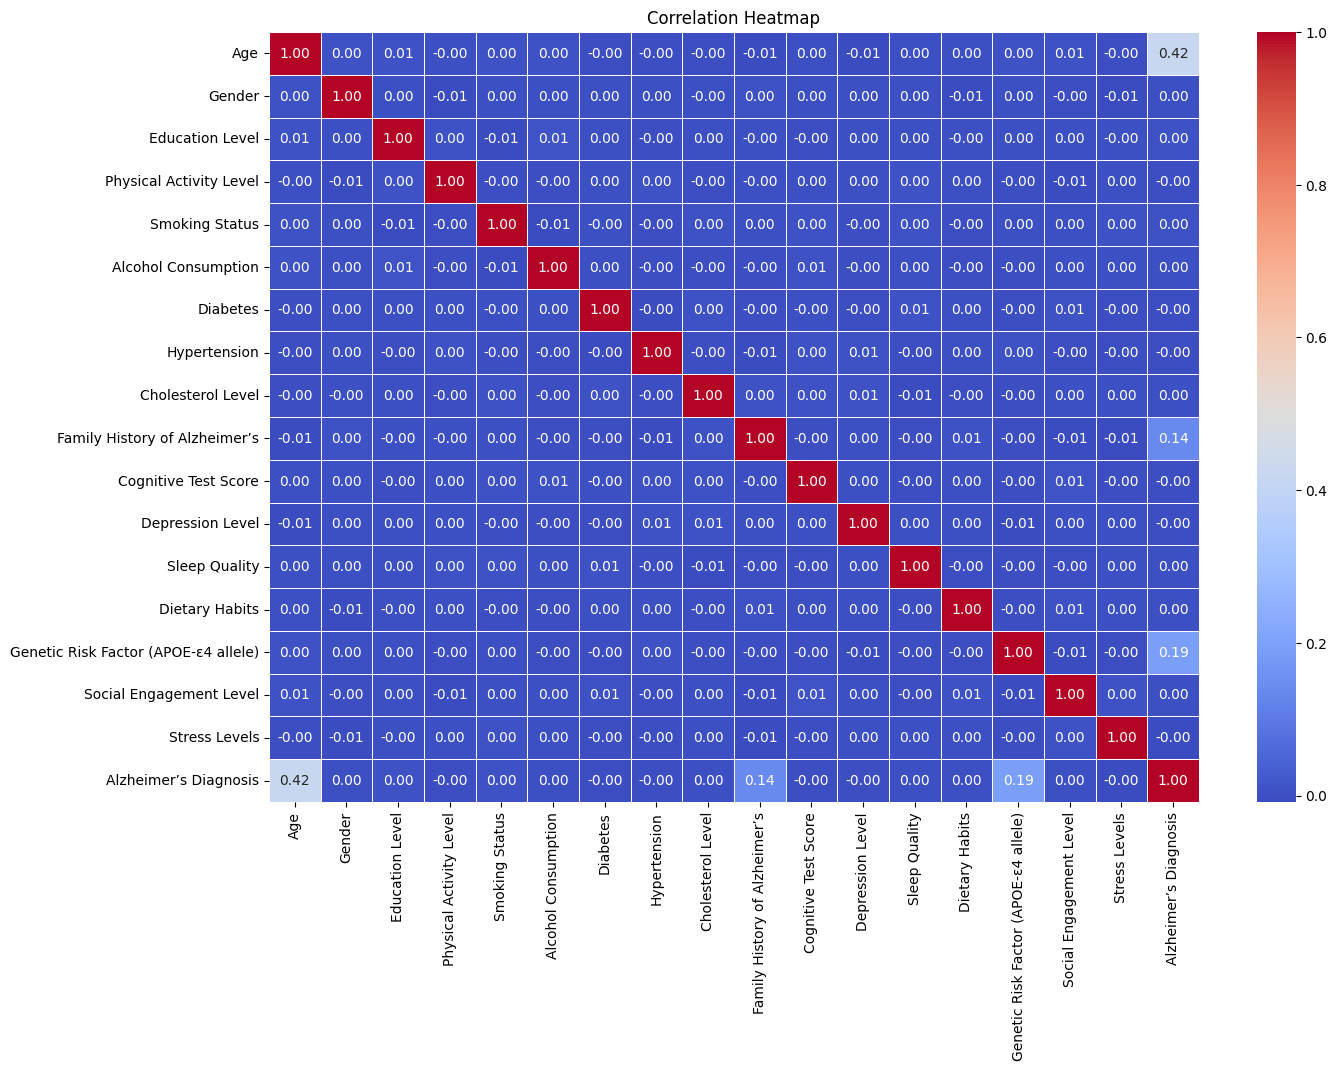

In [66]:
corr_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [67]:
df

,Age,Gender,Education Level,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels,Alzheimer’s Diagnosis
0,90,1,1,2,2,1,0,0,1,0,90,1,2,1,0,1,0,0
1,72,1,7,2,1,0,0,0,1,0,65,1,1,1,0,0,0,0
2,86,0,19,0,0,1,0,1,1,0,43,0,1,0,0,1,0,0
3,53,1,17,1,2,2,1,0,1,0,81,2,0,1,0,0,1,0
4,58,0,3,0,1,0,1,0,1,0,49,0,2,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,60,0,3,0,1,0,0,0,0,0,42,2,2,0,0,2,2,0
74279,58,1,18,1,2,1,1,0,1,0,42,1,2,0,0,2,0,0
74280,57,0,13,2,2,2,0,0,0,1,61,1,1,1,1,0,1,0
74281,73,0,7,1,2,2,0,0,0,0,97,0,1,1,0,1,0,0


In [68]:
X = df.drop(columns=['Alzheimer’s Diagnosis']) 
y = df['Alzheimer’s Diagnosis']

In [69]:
X

,Age,Gender,Education Level,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels
0,90,1,1,2,2,1,0,0,1,0,90,1,2,1,0,1,0
1,72,1,7,2,1,0,0,0,1,0,65,1,1,1,0,0,0
2,86,0,19,0,0,1,0,1,1,0,43,0,1,0,0,1,0
3,53,1,17,1,2,2,1,0,1,0,81,2,0,1,0,0,1
4,58,0,3,0,1,0,1,0,1,0,49,0,2,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,60,0,3,0,1,0,0,0,0,0,42,2,2,0,0,2,2
74279,58,1,18,1,2,1,1,0,1,0,42,1,2,0,0,2,0
74280,57,0,13,2,2,2,0,0,0,1,61,1,1,1,1,0,1
74281,73,0,7,1,2,2,0,0,0,0,97,0,1,1,0,1,0


In [70]:
y

0        0
1        0
2        0
3        0
4        0
        ..
74278    0
74279    0
74280    0
74281    0
74282    0
Name: Alzheimer’s Diagnosis, Length: 74283, dtype: int64

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [72]:
model = LogisticRegression(max_iter=100)


In [73]:
model.fit(X_train,y_train)


LogisticRegression()

In [74]:
model.score(X_train,y_train)


0.7111197119106115

In [75]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

In [76]:
scores2 =  cross_val_score(LogisticRegression(solver='liblinear',multi_class='ovr'), X,y,cv=70)
scores2

array([0.71374765, 0.69020716, 0.71468927, 0.71845574, 0.68455744,
       0.71186441, 0.69491525, 0.7165725 , 0.69679849, 0.72881356,
       0.71374765, 0.68361582, 0.71186441, 0.67577757, 0.71536287,
       0.70499529, 0.74835061, 0.70593779, 0.69462771, 0.72290292,
       0.70028275, 0.73515551, 0.71442036, 0.71253534, 0.70028275,
       0.70970782, 0.70593779, 0.72667295, 0.6927427 , 0.72761546,
       0.68803016, 0.70970782, 0.70970782, 0.71253534, 0.72478794,
       0.70028275, 0.72573044, 0.71159284, 0.68520264, 0.7068803 ,
       0.71913289, 0.69557022, 0.71442036, 0.73704053, 0.70216777,
       0.69839774, 0.70593779, 0.70216777, 0.70216777, 0.68614515,
       0.7200754 , 0.71065033, 0.71159284, 0.7332705 , 0.69462771,
       0.70970782, 0.72761546, 0.72290292, 0.68614515, 0.70122526,
       0.72290292, 0.73704053, 0.73138549, 0.72667295, 0.69745523,
       0.70782281, 0.71065033, 0.72667295, 0.71630537, 0.71536287])

In [77]:
np.average(scores2)


np.float64(0.7102978342622747)

In [78]:
from xgboost import XGBClassifier


In [79]:
xgb = XGBClassifier(n_estimators= 10 , max_depth= 5 , learning_rate = 0.001 )


In [80]:
xgb.fit(X_train , y_train)


XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.001, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=10, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [81]:
xgb.score(X_train , y_train)


0.7263655638945916

In [82]:
xgb.score(X_test , y_test)


0.7296224002153867

In [83]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=32 ,  min_samples_leaf = 1,min_samples_split = 2)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=32)

In [84]:
tree_model.score(X_test, y_test)

0.7296897085548899

In [85]:
tree_model.score(X_train, y_train)

0.7262814256386093

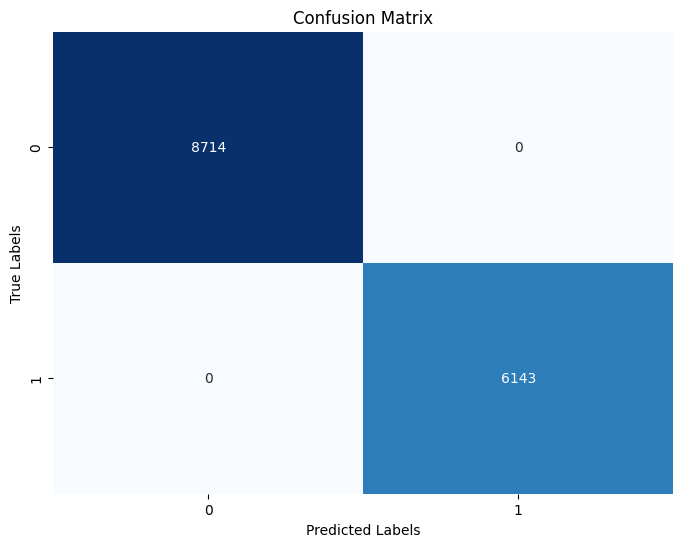

In [86]:
tree_model= confusion_matrix(y_test, y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(tree_model, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()